**WorkFlow**:

Diabetes Data

↓

Data Visualization

↓

Data PreProcessing -> StandardScaler make sure every data is equally distributed

↓

Train Test Split Dataset

↓

Support Vector Machine Classifier Model

↓

Train the Model

↓

Data Evaluation

↓

Make Predictions


In [1]:
# import librares

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

Data Analysis

In [2]:
# Read file

diabetes_data = pd.read_csv('diabetes.csv')

diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
diabetes_data.shape

(768, 9)

In [4]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Look for any null data
diabetes_data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
diabetes_data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 -> Non Diabetic
1 -> Diabetic

In [7]:
diabetes_data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


#Data Visualization

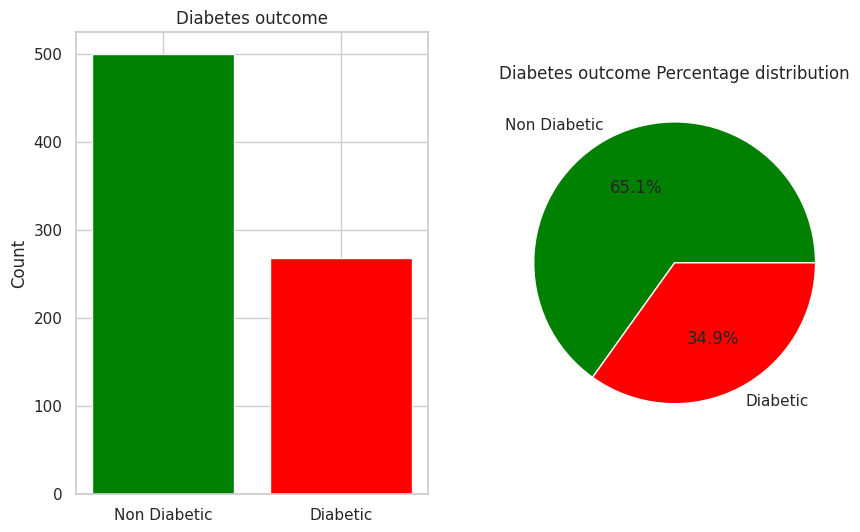

In [15]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)

outcome_data = diabetes_data['Outcome'].value_counts()

plt.bar(['Non Diabetic', 'Diabetic'], outcome_data.values, color=['green', 'red'])
plt.title("Diabetes outcome")
plt.ylabel("Count")

plt.subplot(1,2,2) #Row, col, index
plt.pie(outcome_data.values, labels=['Non Diabetic', 'Diabetic'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Diabetes outcome Percentage distribution")

plt.show()

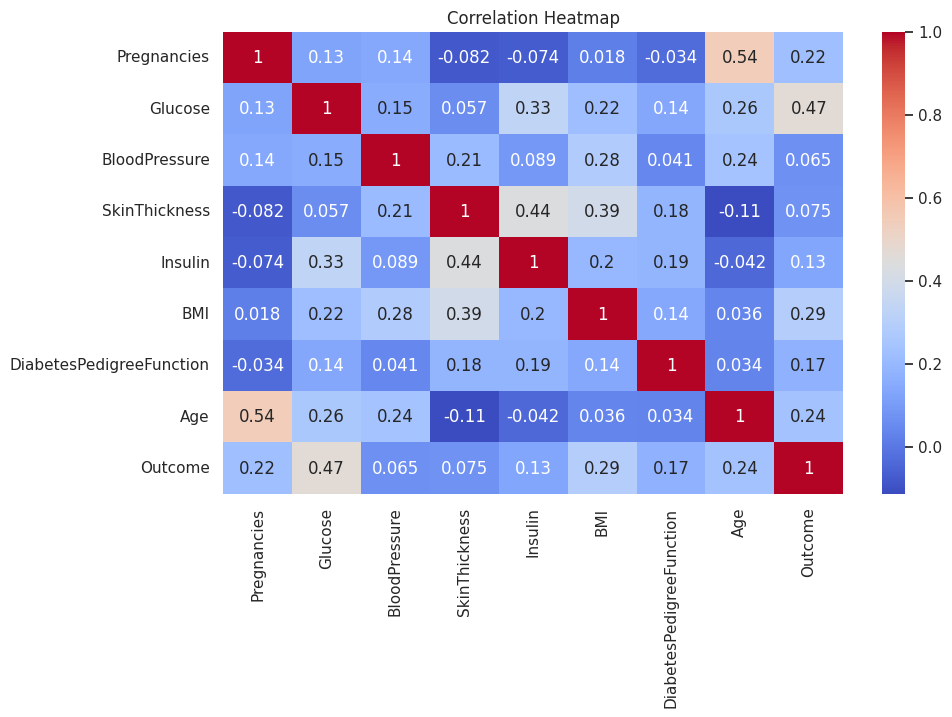

In [16]:
plt.figure(figsize=(10,6))
correlation = diabetes_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

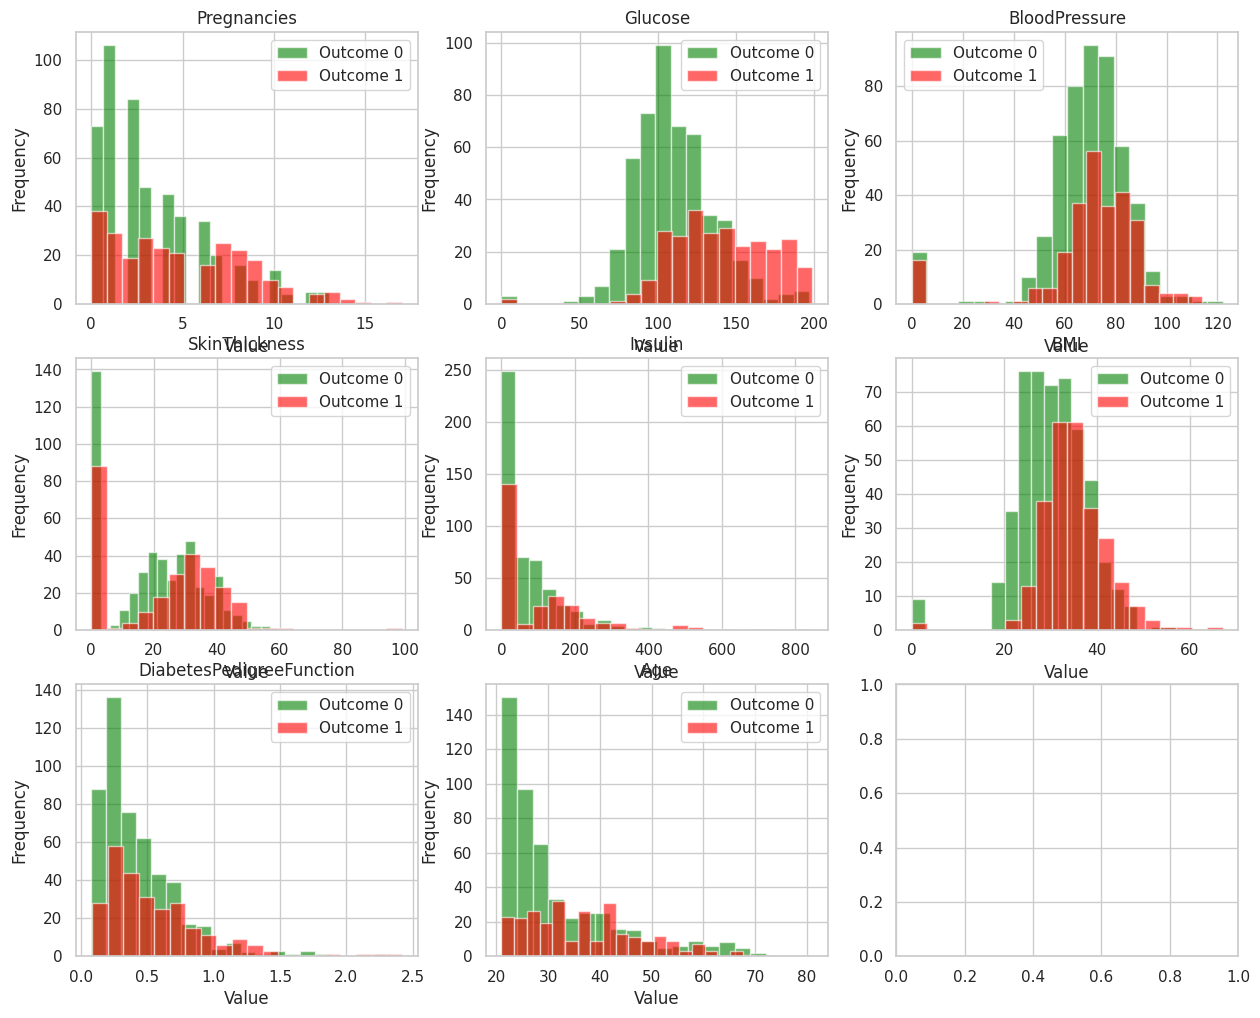

In [22]:
fig, ax = plt.subplots(3,3, figsize=(15,12))
features = diabetes_data.columns[:-1]

for idx, feature in enumerate(features):
  row, col = idx // 3, idx%3

  for outcome in [0,1]:
    data = diabetes_data[diabetes_data['Outcome'] == outcome][feature]
    ax[row, col].hist(data, alpha=0.6, bins=20, label=f'Outcome {outcome}', color=['green','red'][outcome])
    ax[row, col].set_title(feature)
    ax[row, col].set_xlabel('Value')
    ax[row, col].set_ylabel('Frequency')
    ax[row, col].legend()
plt.show



#Data Preprocessing

In [23]:
X = diabetes_data.drop(columns = 'Outcome', axis = 1) #when dropping a col axis=1 and 0 in case of rows
y = diabetes_data['Outcome']

print(X)
print("******************")
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


Data Standaridization is requried because the range of every data is not common or equally distributed

In [24]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

X

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

Now all of the data lies with thin the same range

# Training the dataset

- Sratify helps to distribute the data based on y, so that every data of 0,1 should be there in train and test. Else there might be a chance where whole 1 data is in training and rest 0th in the test, to avoid such we use stratify

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)


(768, 8) (614, 8) (154, 8)


# Model Training

- SVC means Support Vector Classifier
- Kernel means which model we will be using in this case linear

In [26]:
classifier = svm.SVC(kernel='linear', probability=True)

In [27]:
classifier.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

# Model Evaluation
finding the acuracy score

In [28]:
X_train_prediction = classifier.predict(X_train)
training_accuracy = accuracy_score(X_train_prediction, y_train)

(training_accuracy)

0.7866449511400652

In [29]:
X_test_prediction = classifier.predict(X_test)
testing_accuracy = accuracy_score(X_test_prediction, y_test)

(testing_accuracy)

0.7727272727272727

In [31]:
precision = precision_score(y_test, X_test_prediction)

recall = recall_score(y_test, X_test_prediction)

f1 = f1_score(y_test, X_test_prediction)

print(precision, recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [32]:
cm_svm = confusion_matrix(y_test, X_test_prediction)

cm_svm

array([[91,  9],
       [26, 28]])

Text(91.25, 0.5, 'Actual')

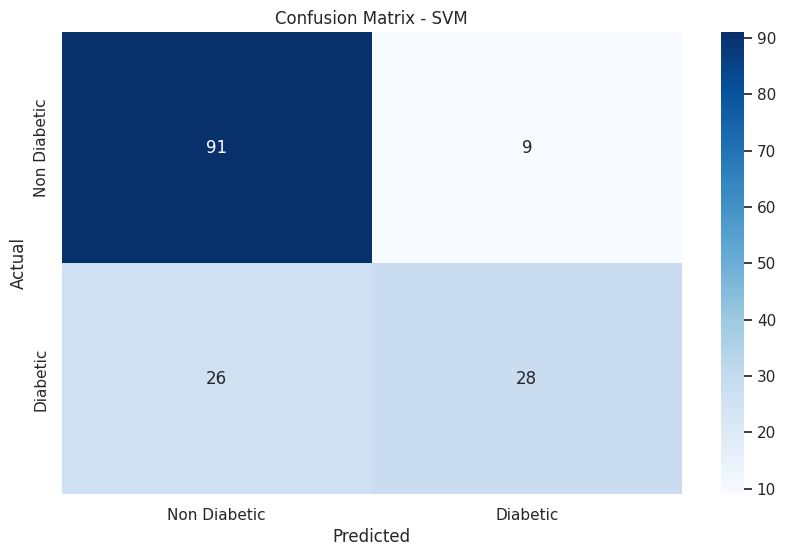

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(cm_svm, annot=True, cmap='Blues', xticklabels=['Non Diabetic', 'Diabetic'], yticklabels=['Non Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [38]:
# Another model -> Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=2)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=2)

In [39]:
x_train_prediction_rf = rf_classifier.predict(X_train)
training_accuracy_rf = accuracy_score(x_train_prediction_rf, y_train)

(training_accuracy_rf)

1.0

In [40]:
x_test_prediction_rf = rf_classifier.predict(X_test)
testing_accuracy_rf = accuracy_score(x_test_prediction_rf, y_test)

(testing_accuracy_rf)

0.7272727272727273

In [41]:
precision = precision_score(y_test, x_test_prediction_rf)

recall = recall_score(y_test, x_test_prediction_rf)

f1 = f1_score(y_test, x_test_prediction_rf)

print(precision, recall, f1)

0.65 0.48148148148148145 0.5531914893617021


In [43]:
cm_svm_rf = confusion_matrix(y_test, x_test_prediction_rf)

cm_svm_rf

array([[86, 14],
       [28, 26]])

Text(91.25, 0.5, 'Actual')

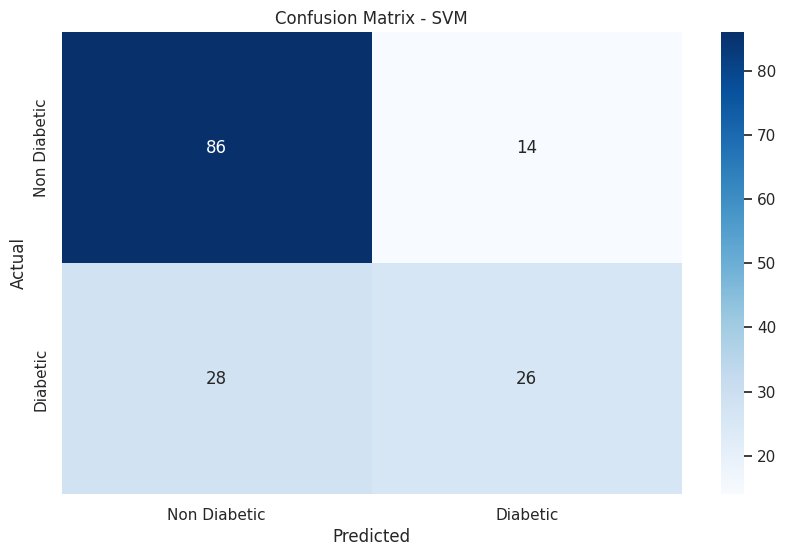

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(cm_svm_rf, annot=True, cmap='Blues', xticklabels=['Non Diabetic', 'Diabetic'], yticklabels=['Non Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')